# 03 · 打浦桥天际线变化(只调高度)
**锁死 footprint 与角色标签,只放开高度这一个自由度**,先看同一个打浦桥街道在四种协商情境下如何改写天际线。

这一本和 `04_进阶-权力算子` 使用同一组情境名称,但只做高度重分配:它回答“谁多拿容量”;04 再回答“这些权利如何改写通行、界面、时间与安全的几何形态”。

> 当前地点应为 `config.py` 的 `SLUG = "dapuqiao"`。可改三处:
> - `config.py` 的 `SLUG` —— 换站点。改完重跑下面「准备」格。
> - `shanghai_lookup.yaml` —— 谁算谁的。改完重跑 **Step 2**。
> - `power_scenarios.yaml` —— 每个情境的高度政策(mult / cap_m / _mode)。改完重跑 **Step 3、4**。


## 怎么执行
- 点一格,按 **Shift+Enter** 执行;或选单 Run → Run All Cells 从头跑。
- 结果与图会显示在该格下面。代码都在 `engine/` 文件夹,平时不用打开。

In [1]:
# 让 notebook 找到 engine 里的代码(这格不用改,直接执行)
import sys, os
sys.path.insert(0, os.path.abspath("engine"))
# 清掉旧的引擎模块缓存:改了 config/engine 后,重跑本格即刻生效(免重启内核)
for _m in [k for k in list(sys.modules) if k in ("config", "common", "operators", "measure")
           or k == "plots" or k.startswith("plots.") or k == "prints" or k.startswith("prints.")]:
    del sys.modules[_m]
import config, common as C, plots, prints
prints.ready()
plots.capture("03")   # 开启自动存图:本册每张图都会存到 out/<slug>/Step_03/<时间戳>/

就绪 ·  当前站点 SLUG = dapuqiao ( 打浦桥街道 )


'20260701_170919'

In [2]:
df = C.current_buildings(config.SLUG)
assert config.SLUG == "dapuqiao", "请先把 config.py 的 SLUG 改成 dapuqiao 后重跑准备格"
df = C.assign_all(df)           # 贴上 stakeholder(改 shanghai_lookup.yaml 可变)
prints.headline(df)


打浦桥街道 · 1370 栋 · 最高 176m


## Step 0(可选):先看真实的地方
卫星底图 + figure-ground(把我们的离散读法叠在真实卫星上)。需要 `contextily` 和网络,没有就跳过。

In [3]:
try:
    plots.satellite_figureground(df)     # 需联网;失败自动跳过
except Exception as e:
    prints.skipped("卫星", e)

跳过卫星(没网或缺 contextily): HTTPSConnectionPool(host='server.arcgisonline.com', port=443): Max retries exceeded with url: /ArcGIS/rest/services/World_Imagery/MapServer/tile/16/26781/54881 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1006)')))


## Step 1:读建筑(实测高度)
这步**还没上色**,全灰,先看清原料:这批楼长什么形状、有多高。上海版高度**全是 AI 实测**,
不是楼层估算——所以才有真正的超高层 token(右图 >100m 的红色)。

  -> saved out\dapuqiao\Step_03\20260701_170919\01_data_overview.png


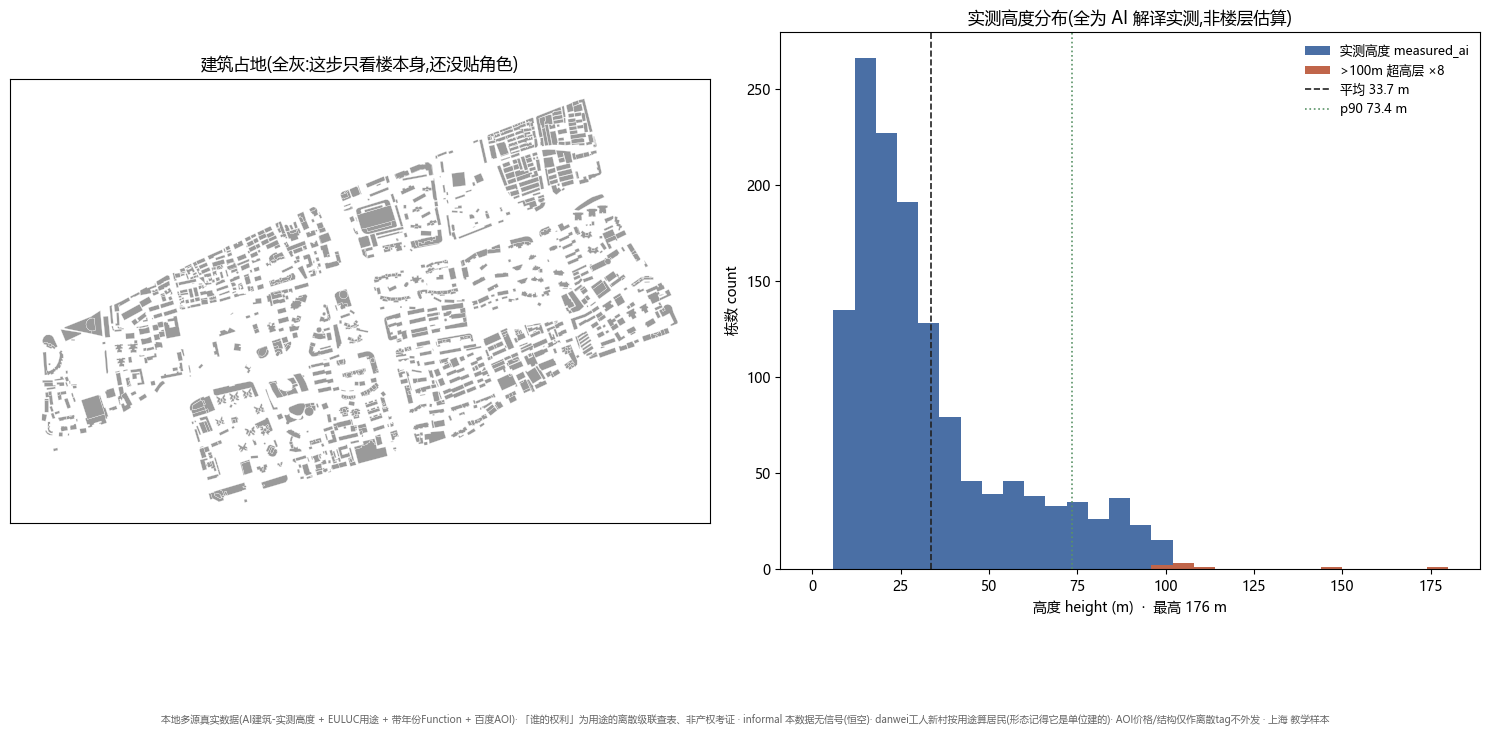

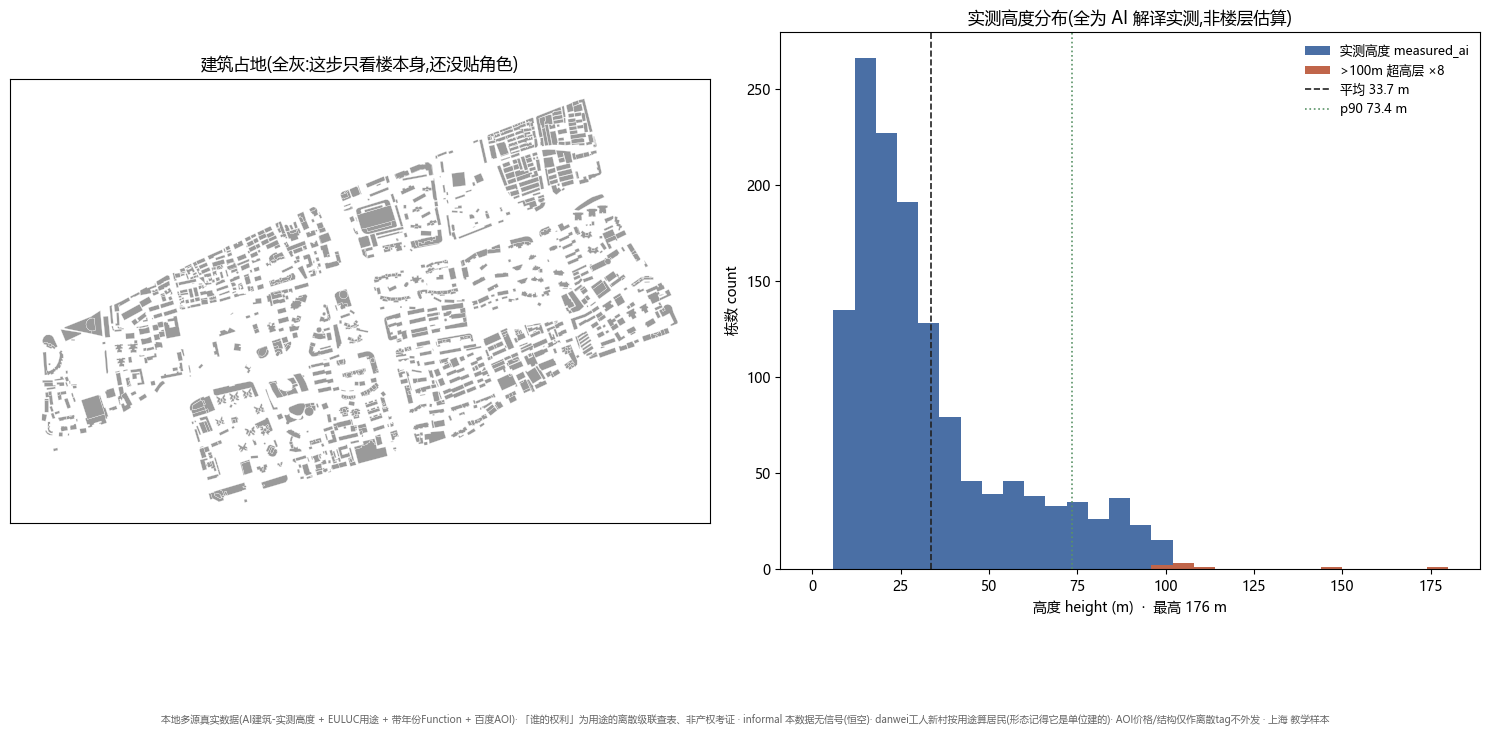

In [4]:
plots.data_overview(df)

## Step 2:贴角色标签
按 `shanghai_lookup.yaml` 的级联查表,给每栋一个角色(详见「02 映射」那本)。只加标签,不动几何与高度。

各角色栋数: {'resident': 780, 'developer': 344, 'state': 183, 'unknown': 63}


  -> saved out\dapuqiao\Step_03\20260701_170919\02_power_map.png


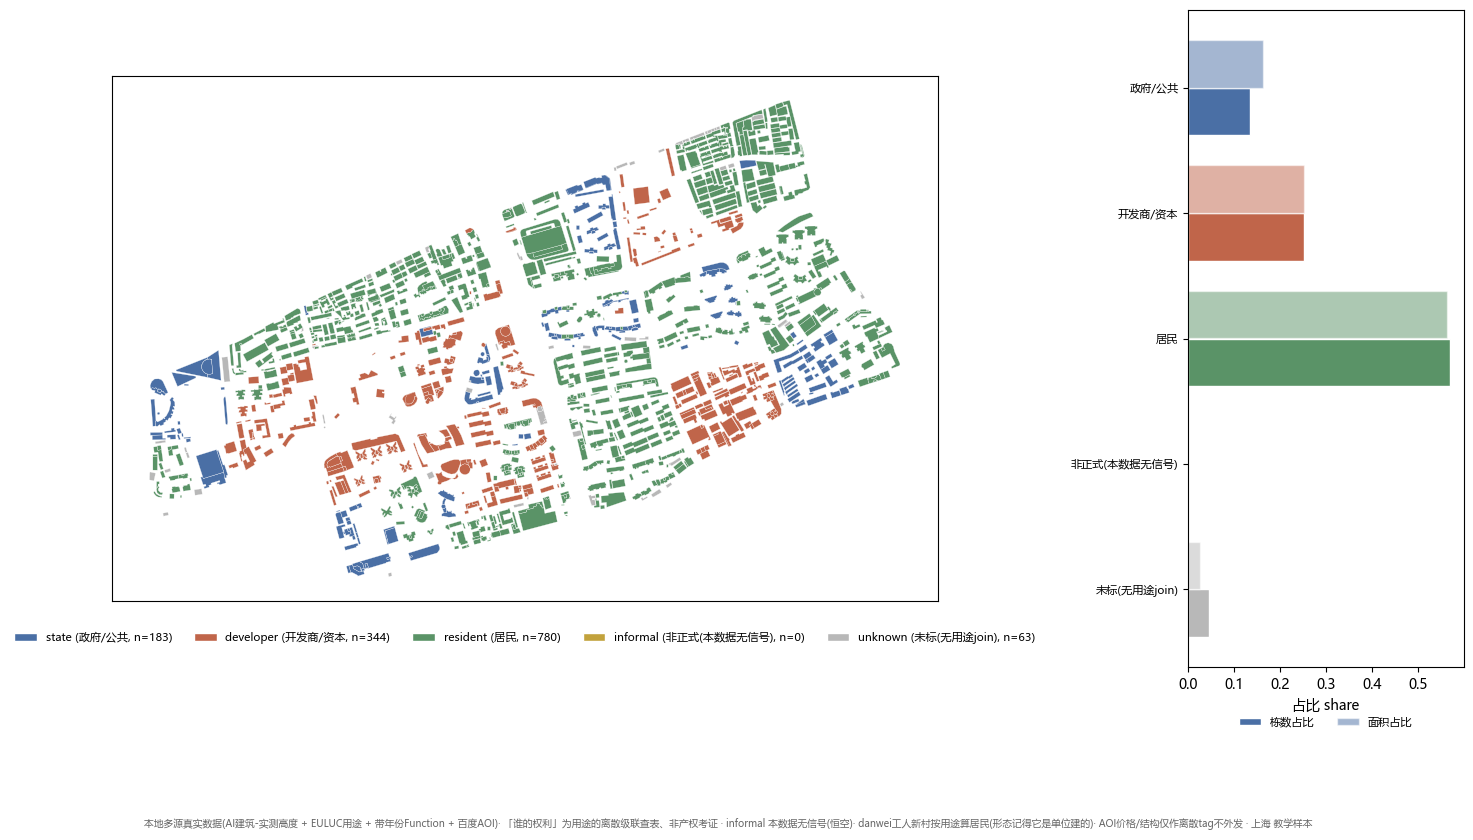

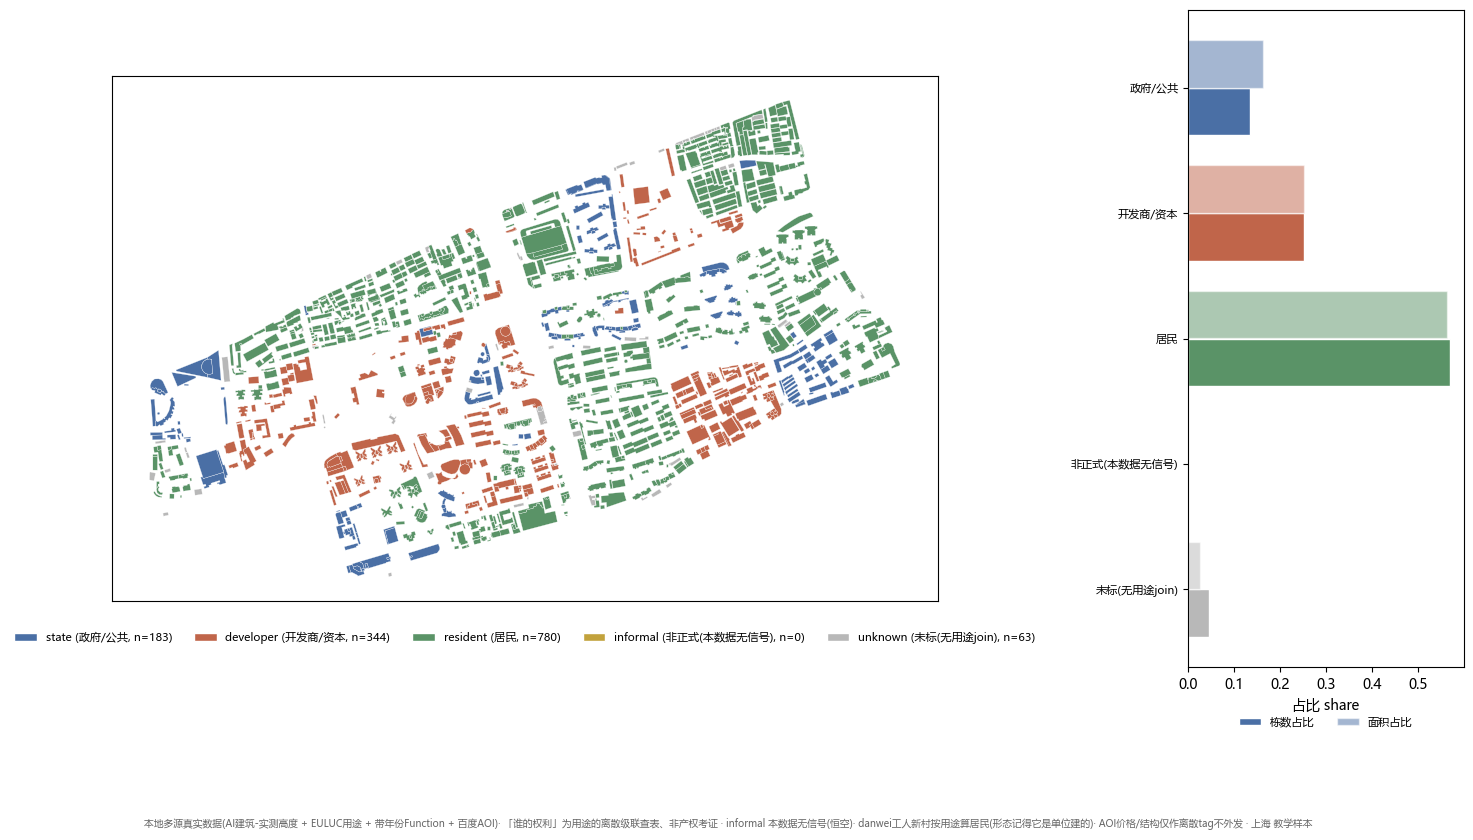

In [5]:
prints.stakeholders(df)
plots.power_map(df)

## Step 3:打浦桥权力情境(高度政策面板)
每个情境给各角色一个高度权重 `mult`、可选上限 `cap_m`,与模式 `_mode`:
- **conserve**(默认):总建筑量守恒,只在角色之间**重分配**。
- **grow**:以现有高度为地板,**只增不减**(都更新增),总量上升。

这里同步 04 的四个打浦桥情境:旅游流量资本主导、居民日常优先、遗产与小商户共生、24小时协商弄堂。


可用情景: ['current', 'tourism_capture', 'everyday_life_first', 'heritage_micro_economy', 'negotiated_24h_alley']


  -> saved out\dapuqiao\Step_03\20260701_170919\03_policy_heatmap.png


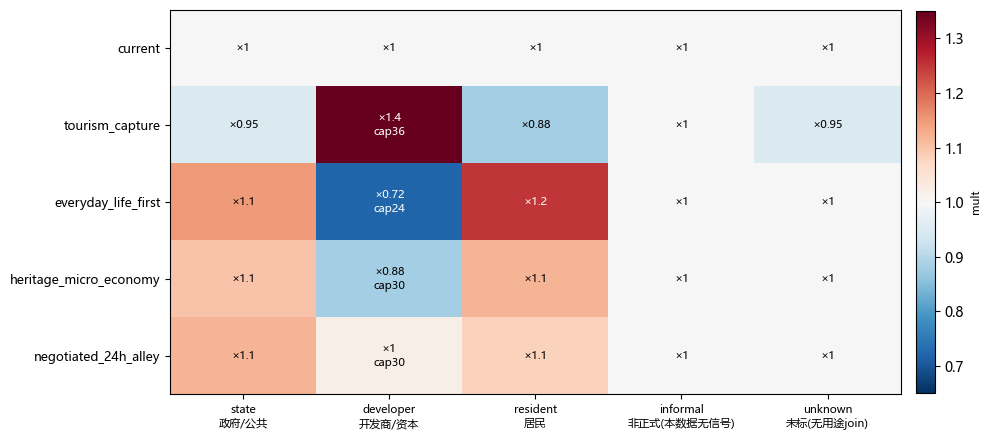

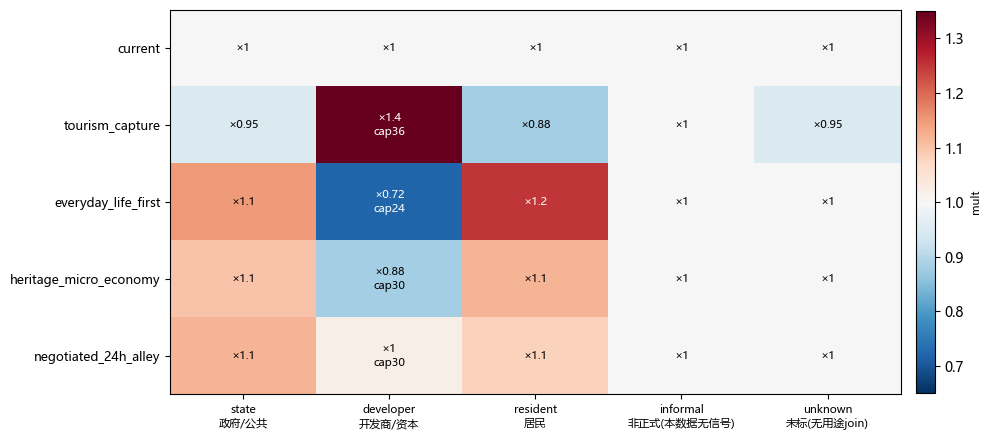

In [6]:
DAPUQIAO_SCENARIO_NAMES = [
    "current",
    "tourism_capture",
    "everyday_life_first",
    "heritage_micro_economy",
    "negotiated_24h_alley",
]
all_scen = C.load_scenarios()
scen = {name: all_scen[name] for name in DAPUQIAO_SCENARIO_NAMES}
prints.scenarios(scen)
plots.policy_heatmap(scen)      # 红=拔高 / 蓝=压低 / 白=照旧


## Step 4:套打浦桥情境,只调高度 —— PAYOFF
同一批楼、同样 footprint 与标签,分别套四个打浦桥情境**只改高度**。因为 footprint 与标签锁定,
天际线差异**完全来自权力配置**。这一步是 04 进阶算子的前置:先看容量如何分配,再看几何如何协商。


  -> saved out\dapuqiao\Step_03\20260701_170919\04_skyline_panels.png


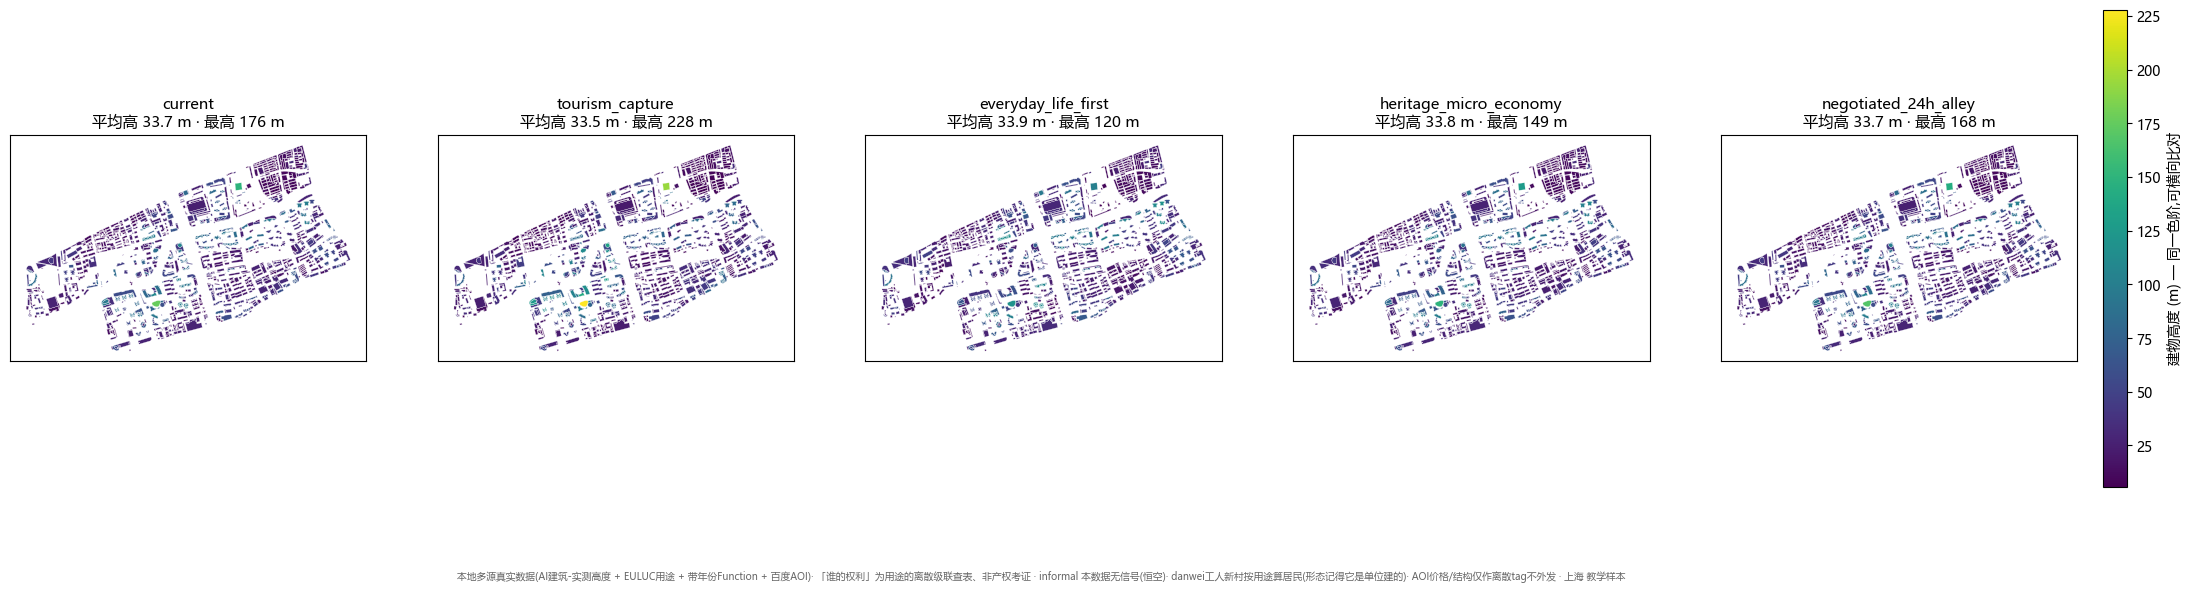

  -> saved out\dapuqiao\Step_03\20260701_170919\05_metrics.png


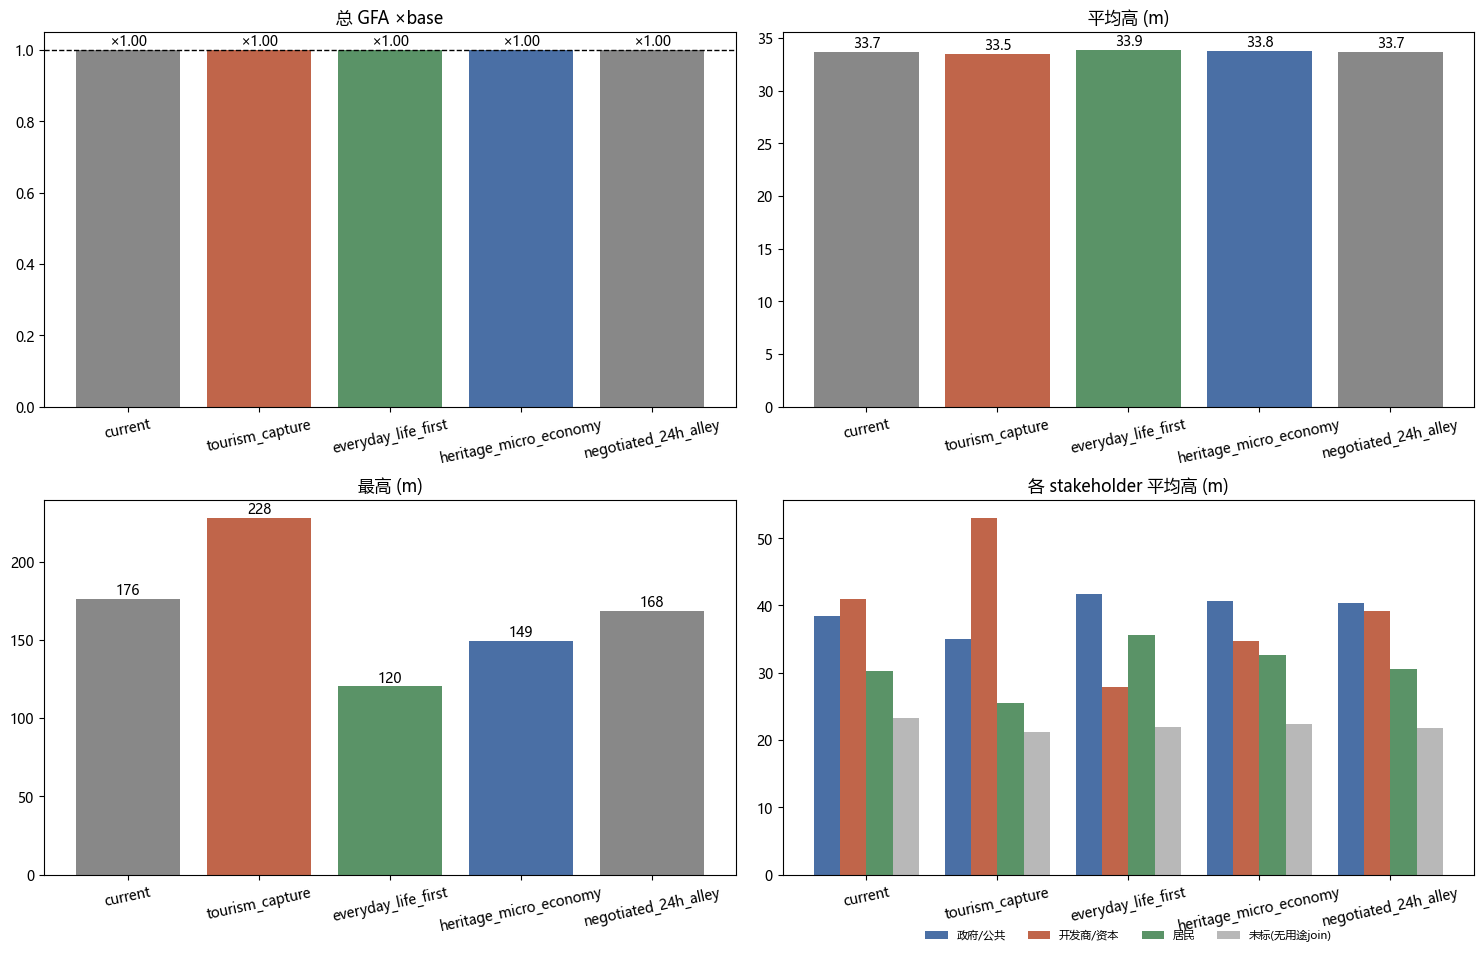

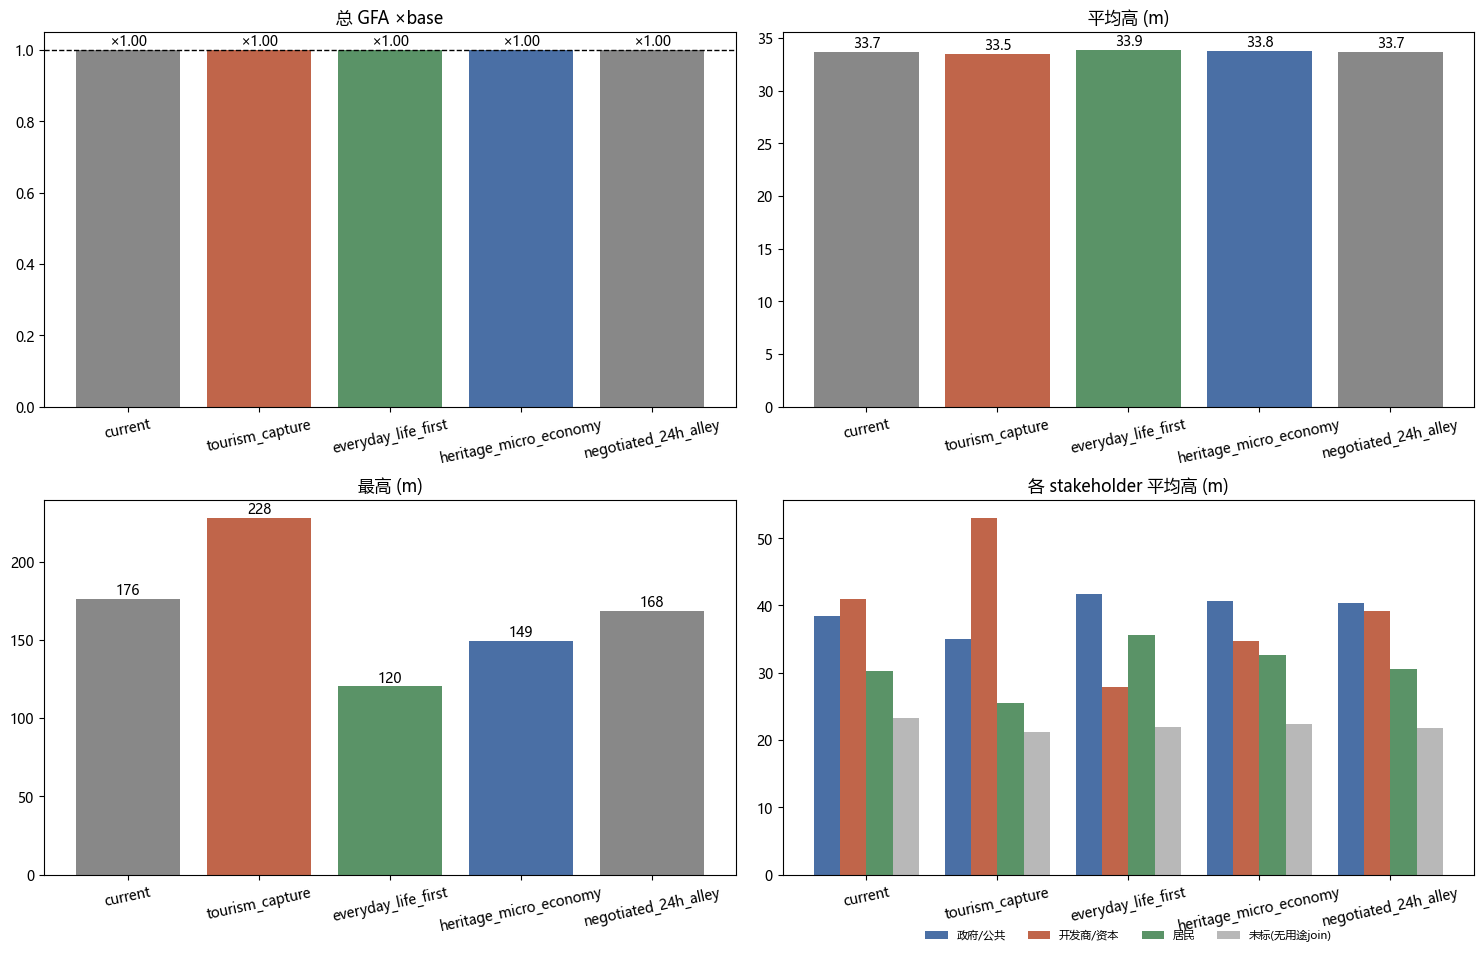

In [7]:
SCEN_NAMES = DAPUQIAO_SCENARIO_NAMES
heights = {n: (C.scenario_heights(df, scen[n]) if n != "current" else df["height_m"]) for n in SCEN_NAMES}
plots.skyline_panels(df, heights, names=SCEN_NAMES)    # 同色阶可横比
plots.metrics(df, heights, names=SCEN_NAMES)           # 总GFA / 平均高 / 最高 / 各角色平均高


## Step 5:出 3D 量体 + OBJ(给 Rhino/GH)
把 footprint 按高度挤成 3D。屏幕预览取占地最大的若干栋(画得快);OBJ 用全部楼、写到 `out/<slug>/`。
这里除现状外,额外预览 `negotiated_24h_alley` 的 3D 天际线,方便和 04 的协商弄堂形态衔接。


  -> saved out\dapuqiao\Step_03\20260701_170919\06_city_3d.png


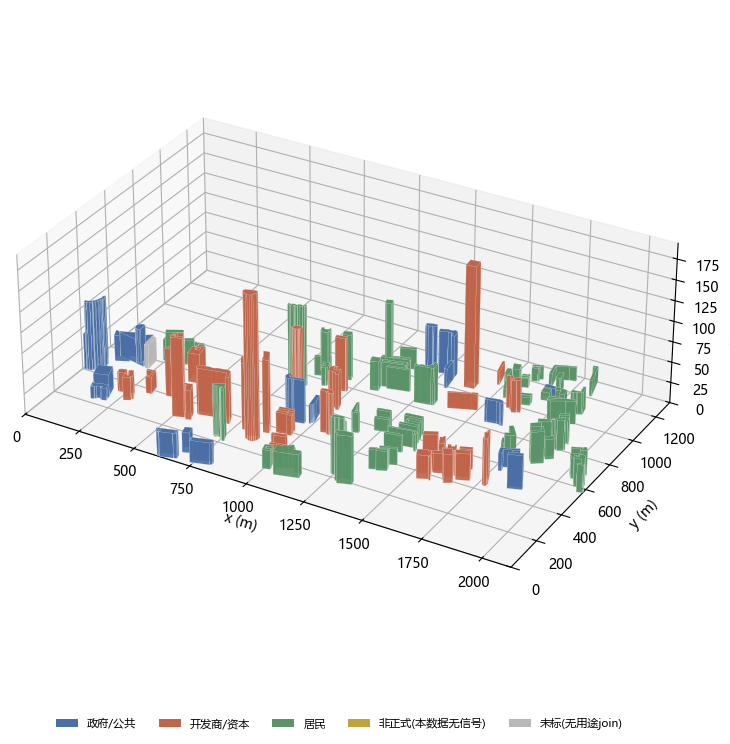

  -> saved out\dapuqiao\Step_03\20260701_170919\07_city_3d.png


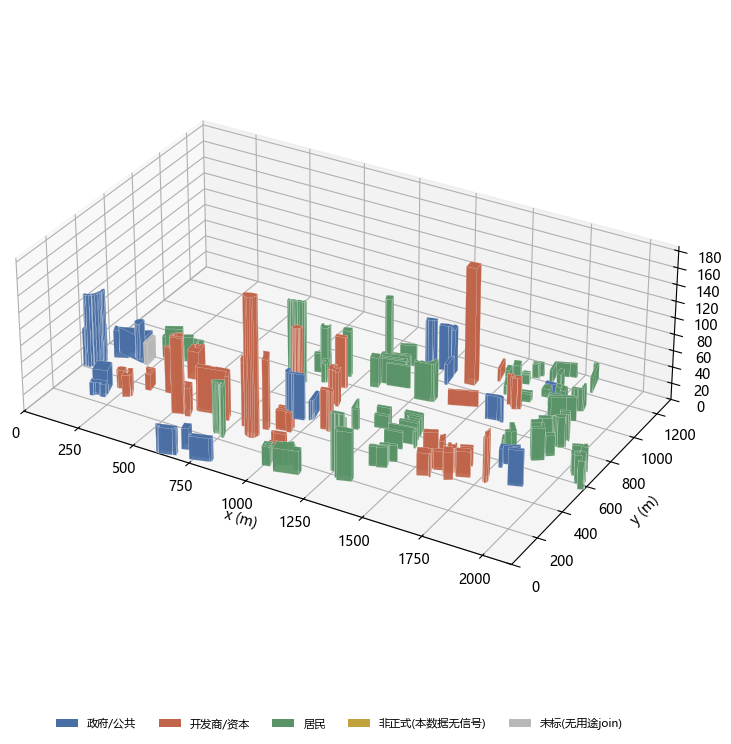

OBJ 写到 out\dapuqiao\city_current.obj  · verts 38480 faces 25272


In [8]:
plots.city_3d(df, top=120)                          # 现状 3D(取占地最大的 120 栋,画得快)
negotiated = df.copy()
negotiated["height_m"] = heights["negotiated_24h_alley"].values
plots.city_3d(negotiated, top=120)                  # 24小时协商弄堂情境的 3D 天际线
path, nv, nf = C.export_obj(df, config.SLUG)         # 全部楼挤成 OBJ → out/<slug>/
prints.obj_written(path, nv, nf)


## 动手练习
改一处、重跑对应步骤,看天际线变化:
- 换站点 → `config.py` 的 `SLUG`(陆家嘴↔曹杨↔豫园)→ 重跑「准备」格起。
- 改谁算谁的 → `shanghai_lookup.yaml` → 重跑 Step 2。
- 改高度政策 / 加情景 → `power_scenarios.yaml` → 重跑 Step 3、4。

> 想让权力不止改高度、而是改**形态语法**(拆板成塔、细粒自建、向权力重心收拢)?
> 进下一本:[`04 进阶-权力算子`]。